# Análise Exploratória e Limpeza de Dados de Vendas com Pandas 🛒

## 1. O Problema de Negócio

**Contexto:** Muitas empresas de e-commerce em fase de expansão sofrem com um problema crônico: possuem um grande volume de dados transacionais, mas não conseguem extrair inteligência deles devido à baixa qualidade do armazenamento bruto. 

**O Desafio:** Atuar em um cenário onde a gestão enfrenta dificuldades para tomar decisões estratégicas devido a problemas estruturais nos dados, tais como:
* **Valores Ausentes:** Pedidos sem registro de quantidade ou status logístico;
* **Inconsistências:** Formatação incorreta (ex: preços cadastrados como texto);
* **Duplicidade:** Registros repetidos que inflavam artificialmente a receita;
* **Outliers:** Dados anômalos que distorciam as médias de vendas.

**Meu Objetivo:** Atuar na engenharia de atributos e limpeza profunda deste banco de dados utilizando `Pandas`. Minha meta final é transformar esse ambiente caótico em um *dataset* confiável, capaz de responder com precisão matemática a três perguntas cruciais:
1. Quais são os produtos e categorias mais lucrativos?
2. Qual é a tendência de vendas ao longo do tempo?
3. Como está a eficiência da operação logística?

## 2. Importação das Bibliotecas

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
# Configura o estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Passo 1 - Geração de Dados Sintéticos com Pandas e NumPy
Criei um DataFrame com dados fictícios que simulam problemas comuns: valores ausentes, tipos de dados incorretos, duplicatas e outliers.

In [ ]:
print("\nGerando conjunto de dados fictícios...")

# Define a semente para garantir reprodutividade
np.random.seed(42)

data = {
    'ID_Pedido': range(1001, 1101),
    'Data_Compra': pd.to_datetime(pd.date_range(start = '2026-07-01', periods = 100, freq ='D')) - pd.to_timedelta(np.random.randint(0, 30, size = 100), unit = 'D'),
    'Cliente_ID': np.random.randint(100, 150, size = 100),
    'Produto': np.random.choice(['Smartphone', 'Notebook', 'Fone de Ouvido', 'Smartwatch', 'Teclado Mecânico'], size = 100),
    'Categoria': ['Eletrônicos', 'Eletrônicos', 'Acessórios', 'Acessórios', 'Acessórios'] * 20,
    'Quantidade': np.random.randint(1, 5, size = 100),
    'Preco_Unitario': [5999.90, 8500.00, 799.50, 2100.00, 850.00] * 20,
    'Status_Entrega': np.random.choice(['Entregue', 'Pendente', 'Cancelado'], size = 100, p = [0.8, 0.15, 0.05])
}

# Cria o dataframe a partir do dicionário acima
df_vendas = pd.DataFrame(data)

# Introduz Problemas nos Dados de Forma Sintética
print("\nIntroduzindo problemas nos dados para a limpeza...\n")

# 1. Valores Ausentes (NaN)
df_vendas.loc[5:10, 'Quantidade'] = np.nan
df_vendas.loc[20:22, 'Status_Entrega'] = np.nan
df_vendas.loc[30, 'Cliente_ID'] = np.nan

# 2. Dados Duplicados
df_vendas = pd.concat([df_vendas, df_vendas.head(3)], ignore_index = True)

# 3. Tipos de Dados Incorretos
df_vendas['Preco_Unitario'] = df_vendas['Preco_Unitario'].astype(str)
df_vendas.loc[15, 'Preco_Unitario'] = 'valor_invalido'              # Simulando um erro de digitação
df_vendas['Cliente_ID'] = df_vendas['Cliente_ID'].astype(str)

# 4. Outliers
df_vendas.loc[50, 'Quantidade'] = 50 # Um valor claramente fora do padrão

print("Dados gerados com sucesso!\n")


Gerando conjunto de dados fictícios...

Introduzindo problemas nos dados para a limpeza...

Dados gerados com sucesso!



C:\Users\rs455\AppData\Local\Temp\ipykernel_4940\4190763659.py:8: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  'Data_Compra': pd.to_datetime(pd.date_range(start = '2026-07-01', periods = 100, freq ='D')) - pd.to_timedelta(np.random.randint(0, 30, size = 100), unit = 'd'),


In [10]:
# Exibe as primeiras linhas
df_vendas.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-25,109.0,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
1,1002,2026-06-13,135.0,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
2,1003,2026-06-05,113.0,Smartwatch,Acessórios,3.0,799.5,Entregue
3,1004,2026-06-20,130.0,Smartwatch,Acessórios,4.0,2100.0,Entregue
4,1005,2026-06-25,147.0,Smartwatch,Acessórios,4.0,850.0,Cancelado


In [11]:
# Exibe as últimas linhas
df_vendas.tail()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
98,1099,2026-09-26,144.0,Fone de Ouvido,Acessórios,4.0,2100.0,Entregue
99,1100,2026-10-07,105.0,Smartphone,Acessórios,1.0,850.0,Entregue
100,1001,2026-06-25,109.0,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
101,1002,2026-06-13,135.0,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
102,1003,2026-06-05,113.0,Smartwatch,Acessórios,3.0,799.5,Entregue


## Passo 2 - Análise Exploratória de Dados (EDA)
Antes de qualquer modificação, primeiro inspeciono o DataFrame para entender sua estrutura e identificar os problemas.

In [12]:
print("\n--- Informações Gerais do DataFrame (df_vendas.info()) ---\n")
df_vendas.info()


--- Informações Gerais do DataFrame (df_vendas.info()) ---

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       103 non-null    int64         
 1   Data_Compra     103 non-null    datetime64[us]
 2   Cliente_ID      102 non-null    str           
 3   Produto         103 non-null    str           
 4   Categoria       103 non-null    str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  103 non-null    str           
 7   Status_Entrega  100 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 6.6 KB


In [13]:
print("\n--- Verificando valores ausentes ---\n")
print(df_vendas.isna().sum())


--- Verificando valores ausentes ---

ID_Pedido         0
Data_Compra       0
Cliente_ID        1
Produto           0
Categoria         0
Quantidade        6
Preco_Unitario    0
Status_Entrega    3
dtype: int64


In [14]:
print("\n--- Verificando a presença de registros duplicados ---\n")
print(f"Número de linhas duplicadas: {df_vendas.duplicated().sum()}")


--- Verificando a presença de registros duplicados ---

Número de linhas duplicadas: 3


In [15]:
print("\n--- Estatísticas descritivas para colunas numéricas ---\n")
# Usei o describe() para ter uma noção inicial. Note que Preco_Unitario não aparecerá por ser 'object'.
print(df_vendas.describe())


--- Estatísticas descritivas para colunas numéricas ---

         ID_Pedido                 Data_Compra  Quantidade
count   103.000000                         103   97.000000
mean   1049.087379  2026-08-02 09:33:12.233009    3.103093
min    1001.000000         2026-06-05 00:00:00    1.000000
25%    1023.500000         2026-07-07 12:00:00    2.000000
50%    1049.000000         2026-07-31 00:00:00    3.000000
75%    1074.500000         2026-08-29 12:00:00    4.000000
max    1100.000000         2026-10-07 00:00:00   50.000000
std      29.733821                         NaN    4.954973


In [ ]:
print("\n--- Estatísticas descritivas para colunas categóricas ---\n")
print(df_vendas.describe(include = ['O']))


--- Estatísticas descritivas para colunas categóricas ---

       Cliente_ID     Produto   Categoria Preco_Unitario Status_Entrega
count         102         103         103            103            100
unique         45           5           2              6              3
top         113.0  Smartwatch  Acessórios         8500.0       Entregue
freq            5          29          61             21             83


C:\Users\rs455\AppData\Local\Temp\ipykernel_4940\2226832125.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_vendas.describe(include = [object]))


In [17]:
print("\n--- Tipos de dados ---\n")
df_vendas.dtypes


--- Tipos de dados ---



ID_Pedido                  int64
Data_Compra       datetime64[us]
Cliente_ID                   str
Produto                      str
Categoria                    str
Quantidade               float64
Preco_Unitario               str
Status_Entrega               str
dtype: object

## Passo 3 - Limpeza e Pré-Processamento dos Dados
Resolvendo sistematicamente os problemas identificados na etapa de inspeção.

In [18]:
# Copiando o DataFrame para manter o original intacto
df_limpo = df_vendas.copy()

In [19]:
# --- 1. Corrigindo Tipos de Dados ---
print("Corrigindo tipos de dados...")
# Converte 'Preco_Unitario' para numérico, tratando erros
# errors='coerce' transformará valores inválidos (como 'valor_invalido') em NaN
df_limpo['Preco_Unitario'] = pd.to_numeric(df_limpo['Preco_Unitario'], errors = 'coerce')

Corrigindo tipos de dados...


In [20]:
# Converte 'Cliente_ID' para numérico, tratando erros
df_limpo['Cliente_ID'] = pd.to_numeric(df_limpo['Cliente_ID'], errors = 'coerce').astype('Int64') # Usa-se Int64 para permitir NaN

In [21]:
# Visualização das modificações
df_limpo.dtypes

ID_Pedido                  int64
Data_Compra       datetime64[us]
Cliente_ID                 Int64
Produto                      str
Categoria                    str
Quantidade               float64
Preco_Unitario           float64
Status_Entrega               str
dtype: object

In [22]:
# --- 2. Tratando Valores Ausentes (NaN) ---
print("Tratando valores ausentes...")
# Para 'Quantidade', preencho com a mediana, que é mais robusta a outliers
mediana_qtd = df_limpo['Quantidade'].median()
df_limpo.fillna({'Quantidade': mediana_qtd}, inplace = True)

Tratando valores ausentes...


,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado
...,...,...,...,...,...,...,...,...
98,1099,2026-09-26,144,Fone de Ouvido,Acessórios,4.0,2100.0,Entregue
99,1100,2026-10-07,105,Smartphone,Acessórios,1.0,850.0,Entregue
100,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
101,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue


In [23]:
# Para 'Status_Entrega', pode-se preencher com o valor mais frequente (moda)
moda_status = df_limpo['Status_Entrega'].mode()[0]
df_limpo['Status_Entrega'] = df_limpo['Status_Entrega'].fillna(moda_status)

In [24]:
# Para 'Preco_Unitario' e 'Cliente_ID', onde o NaN foi gerado por erro ou falta de informação,
# a melhor abordagem é remover as linhas, pois não se pode inferir esses dados.
df_limpo.dropna(subset = ['Preco_Unitario', 'Cliente_ID'], inplace = True)

In [25]:
# --- 3. Removendo Duplicatas ---
print("Removendo registros duplicados...")
df_limpo.drop_duplicates(inplace = True)

Removendo registros duplicados...


Tratando outliers...


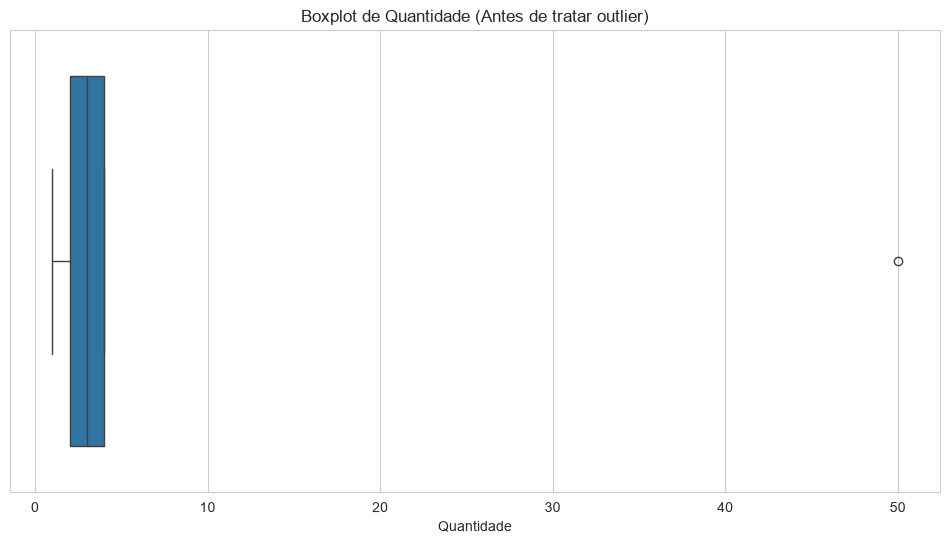

In [26]:
# --- 4. Tratando Outliers ---
# Primeiro, preciso visualizar o outlier na coluna 'Quantidade'
print("Tratando outliers...")
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot de Quantidade (Antes de tratar outlier)')
plt.show()

In [27]:
# Remove valores de 'Quantidade' que estão muito distantes da média,
# uma abordagem comum é remover valores que estão além de 3 desvios padrão da média.
limite_superior = df_limpo['Quantidade'].mean() + 3 * df_limpo['Quantidade'].std()
df_limpo = df_limpo[df_limpo['Quantidade'] < limite_superior]

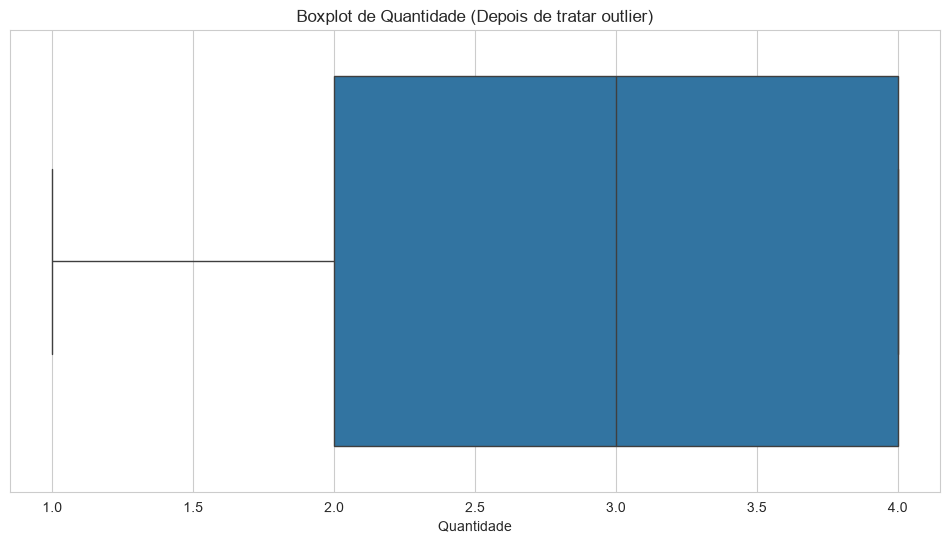

In [28]:
# Verificando o resultado
sns.boxplot(x = df_limpo['Quantidade'])
plt.title('Boxplot de Quantidade (Depois de tratar outlier)')
plt.show()

In [29]:
# --- Verificação Final ---
print("\n--- Verificação Final Pós-Limpeza ---\n")
df_limpo.info()
print("\nValores ausentes restantes:\n", df_limpo.isna().sum())
print(f"\nLinhas duplicadas restantes: {df_limpo.duplicated().sum()}")


--- Verificação Final Pós-Limpeza ---

<class 'pandas.DataFrame'>
Index: 97 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       97 non-null     int64         
 1   Data_Compra     97 non-null     datetime64[us]
 2   Cliente_ID      97 non-null     Int64         
 3   Produto         97 non-null     str           
 4   Categoria       97 non-null     str           
 5   Quantidade      97 non-null     float64       
 6   Preco_Unitario  97 non-null     float64       
 7   Status_Entrega  97 non-null     str           
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.9 KB

Valores ausentes restantes:
 ID_Pedido         0
Data_Compra       0
Cliente_ID        0
Produto           0
Categoria         0
Quantidade        0
Preco_Unitario    0
Status_Entrega    0
dtype: int64

Linhas duplicadas restantes: 0


## Passo 4 - Engenharia de Atributos e Extração de Valor
Com os dados limpos, posso fazer perguntas e extrair valor das análises.

In [30]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado


In [31]:
# --- Feature Engineering: Criando uma nova coluna 'Total_Venda' ---
df_limpo['Total_Venda'] = df_limpo['Quantidade'] * df_limpo['Preco_Unitario']

In [32]:
df_limpo.head()

,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega,Total_Venda
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado,5999.9
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue,25500.0
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue,2398.5
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue,8400.0
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado,3400.0


In [33]:
# 1. Qual o total de receita?
receita_total = df_limpo['Total_Venda'].sum()
print(f"A receita total da loja foi de: R$ {receita_total:,.2f}")

A receita total da loja foi de: R$ 928,869.00


In [34]:
# 2. Qual a receita total por categoria de produto?
receita_por_categoria = df_limpo.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending = False)
print("\n--- Receita Total por Categoria ---\n")
print(receita_por_categoria)


--- Receita Total por Categoria ---

Categoria
Eletrônicos    733495.0
Acessórios     195374.0
Name: Total_Venda, dtype: float64


In [35]:
# 3. Qual o produto mais vendido em quantidade?
produto_mais_vendido = df_limpo.groupby('Produto')['Quantidade'].sum().sort_values(ascending = False)
print("\n--- Total de Unidades Vendidas por Produto ---\n")
print(produto_mais_vendido)


--- Total de Unidades Vendidas por Produto ---

Produto
Smartphone          84.0
Fone de Ouvido      61.0
Smartwatch          59.0
Notebook            32.0
Teclado Mecânico    20.0
Name: Quantidade, dtype: float64


In [36]:
# 4. Análise de vendas ao longo do tempo (agrupando as vendas por dia)
vendas_por_dia = df_limpo.set_index('Data_Compra').resample('D')['Total_Venda'].sum()
print("\n--- Resumo de Vendas por Dia (Primeiros 5 dias) ---\n")
print(vendas_por_dia.head())


--- Resumo de Vendas por Dia (Primeiros 5 dias) ---

Data_Compra
2026-06-05     2398.5
2026-06-06        0.0
2026-06-07        0.0
2026-06-08        0.0
2026-06-09    25500.0
Freq: D, Name: Total_Venda, dtype: float64


## Passo 5 - Visualização dos Dados e Análise


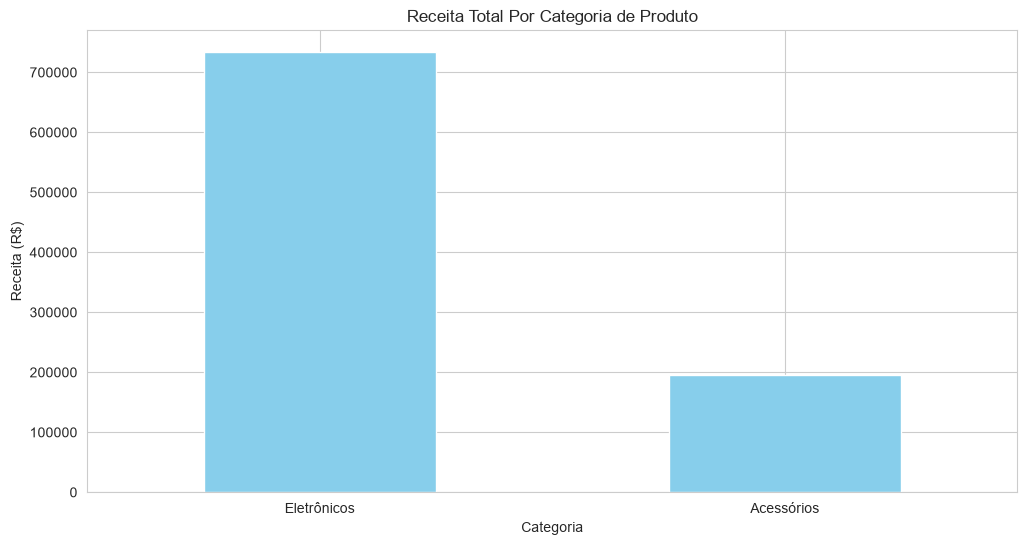

In [37]:
# Gráfico 1: Receita por Categoria
receita_por_categoria.plot(kind = 'bar', color = 'skyblue')
plt.title('Receita Total Por Categoria de Produto')
plt.ylabel('Receita (R$)')
plt.xlabel('Categoria')
plt.xticks(rotation = 0)
plt.show()

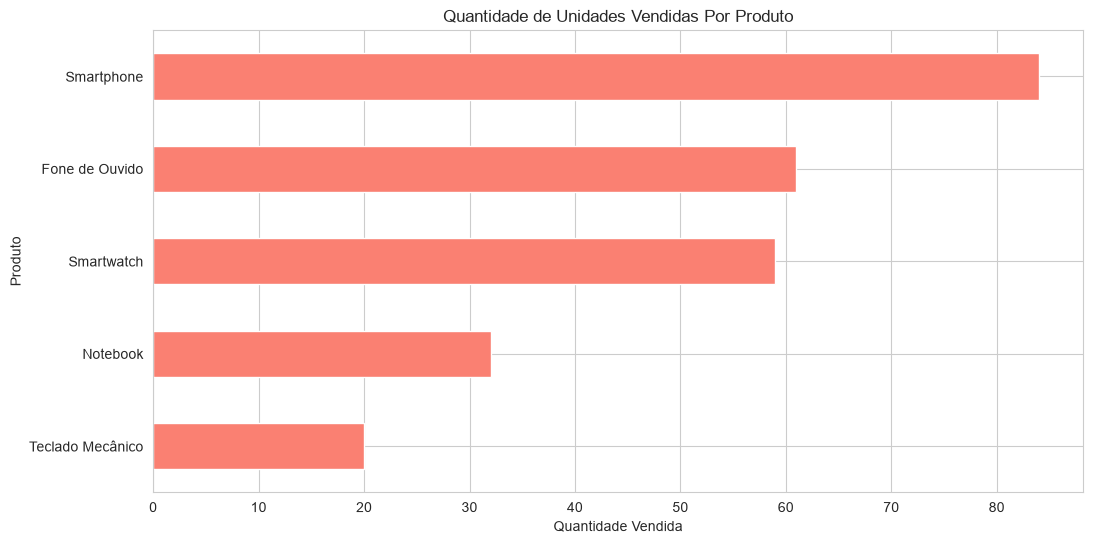

In [38]:
# Gráfico 2: Quantidade Vendida por Produto
produto_mais_vendido.plot(kind = 'barh', color = 'salmon')
plt.title('Quantidade de Unidades Vendidas Por Produto')
plt.ylabel('Produto')
plt.xlabel('Quantidade Vendida')
plt.gca().invert_yaxis() # Inverte o eixo para o maior valor ficar no topo
plt.show()

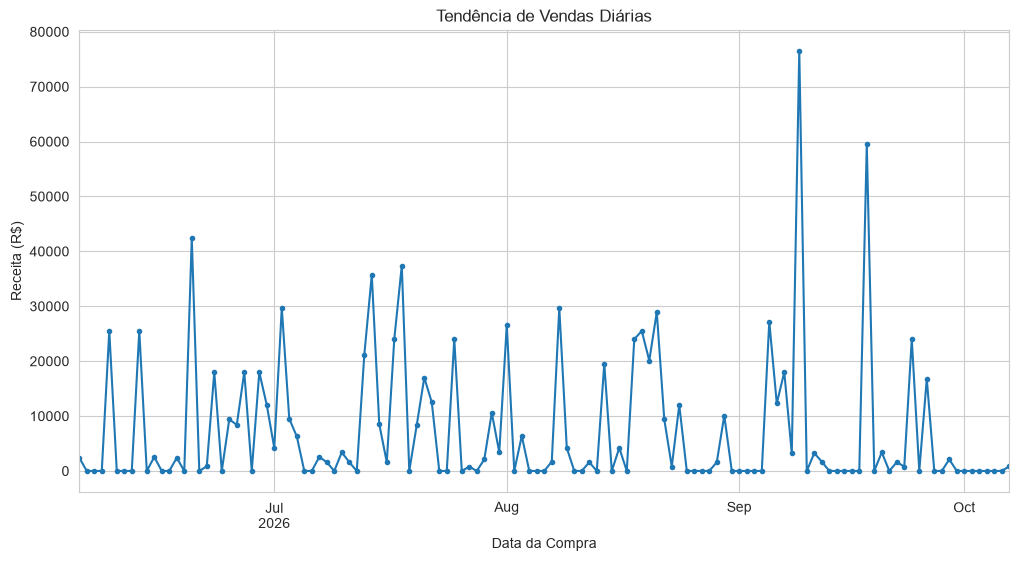

In [39]:
# Gráfico 3: Tendência de Vendas ao Longo do Tempo
vendas_por_dia.plot(kind = 'line', marker = '.', linestyle = '-')
plt.title('Tendência de Vendas Diárias')
plt.ylabel('Receita (R$)')
plt.xlabel('Data da Compra')
plt.grid(True)
plt.show()

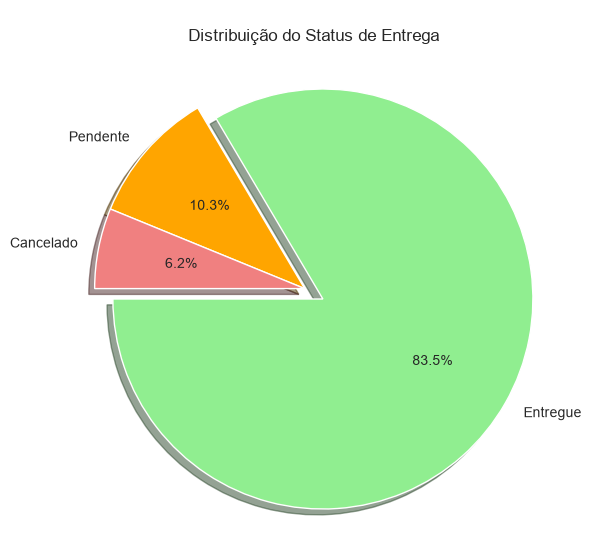

In [40]:
# Gráfico 4: Distribuição do Status de Entrega no formato 3D

# Conta quantas vezes aparece cada status de entrega
status_counts = df_limpo['Status_Entrega'].value_counts()

# Descobre a posição (índice) da fatia com maior valor para destacá-la
maior_idx = status_counts.argmax()

# Cria a lista explode: desloca 0.1 para a maior fatia e 0 para as outras
explode = [0.1 if i == maior_idx else 0 for i in range(len(status_counts))]

plt.figure(figsize = (6,6))

plt.pie(
    status_counts,                 
    labels = status_counts.index,  
    autopct = '%1.1f%%',           
    startangle = 180,              
    colors = ['lightgreen',        
              'orange',            
              'lightcoral'],       
    explode = explode,             
    shadow = True                  
)

plt.title('\nDistribuição do Status de Entrega\n')  
plt.axis('equal')                                   
plt.show()                                                               

## 7. Relatório Final e Conclusão

Após executar todo o ciclo de engenharia de dados — que incluiu o diagnóstico de anomalias, tratamento de valores ausentes, eliminação de registros duplicados, correção de tipos textuais/numéricos e filtragem de *outliers* —, consegui transformar um banco de dados transacional corrompido em uma fonte confiável para a tomada de decisão.

As visualizações gráficas geradas permitiram extrair as seguintes conclusões estratégicas:

1. **Confiabilidade Operacional:** A limpeza revelou que a grande maioria dos pedidos segue um fluxo saudável de entrega, permitindo que a diretoria enxergue o volume real de gargalos logísticos sem a distorção de dados corrompidos ou duplicados.
2. **Impacto da Qualidade de Dados (Data Quality):** A correção dos preços e das quantidades garantiu que métricas cruciais, como faturamento por categoria e ticket médio, passassem a refletir a realidade financeira exata da operação, eliminando prejuízos causados por relatórios falsificados por erros de sistema.
3. **Visão de Negócio:** Com o *dataset* devidamente estruturado, a empresa agora possui uma base sólida para implementar modelos preditivos futuros ou automatizar dashboards gerenciais de vendas.

Este projeto reforça que a análise exploratória e a limpeza de dados (*Data Cleaning*) representam a etapa mais crítica e fundacional de qualquer iniciativa em Ciência de Dados. Sem dados limpos, qualquer inteligência de negócio gerada posteriormente seria baseada em premissas falsas.